In [1]:
#BAI 1
import pandas as pd

df = pd.read_csv("/content/gia_nha.csv")

# Lọc những căn có diện tích lớn hơn 100 m2
nhom_lon = df[df["dien_tich"] > 100]

# In số lượng căn
print("So can co dien tich lon hon 100 m2:", len(nhom_lon))

# In giá trung bình
print("Gia trung binh:", round(nhom_lon["gia"].mean(), 3), "ty dong")

So can co dien tich lon hon 100 m2: 12
Gia trung binh: 8.775 ty dong


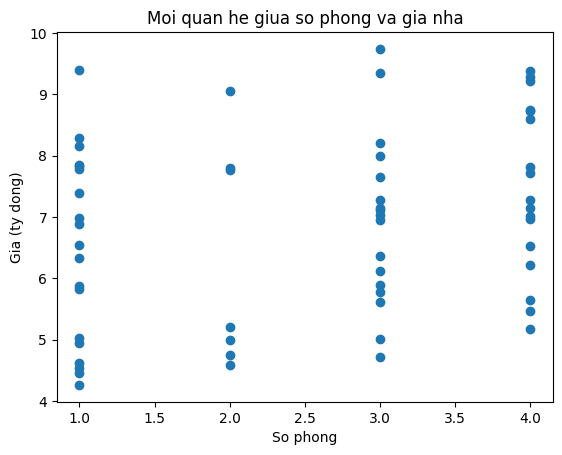

In [6]:
#bài 2:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("/content/gia_nha.csv")

# Vẽ biểu đồ phân tán giữa số phòng và giá nhà
plt.scatter(df["so_phong"], df["gia"])

# Đặt tên cho hai trục
plt.xlabel("So phong")
plt.ylabel("Gia (ty dong)")

# Đặt tiêu đề cho biểu đồ
plt.title("Moi quan he giua so phong va gia nha")

# Lưu hình trước khi hiển thị
plt.savefig("bai2.png", dpi=150)

# Hiển thị biểu đồ
plt.show()


Nhận xét: Nhìn chung, số phòng càng nhiều thì giá nhà có xu hướng cao hơn, tuy nhiên giá nhà vẫn có sự phân tán giữa các căn.

In [4]:
#bài 3:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("/content/gia_nha.csv")

# Chọn tuổi nhà làm biến đầu vào và giá làm biến cần dự đoán
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

# Tính trung bình
x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

# In kết quả với 6 chữ số sau dấu phẩy
print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")

He so goc w = -0.027400
He so chan b = 7.181307


Nhận xét: Hệ số góc w mang dấu âm, cho thấy khi tuổi nhà tăng thêm một năm thì giá nhà có xu hướng giảm. Tuy nhiên, dấu âm của w chỉ thể hiện chiều của mối quan hệ, chưa đủ để kết luận hai biến có quan hệ chặt chẽ. Nếu các điểm dữ liệu phân tán xa đường thẳng thì mối quan hệ giữa tuổi nhà và giá nhà không quá rõ ràng.

In [5]:
#bài 4
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Đọc dữ liệu
df = pd.read_csv("/content/gia_nha.csv")

# Hai biến đầu vào
X = df[["dien_tich", "so_phong"]]

# Biến cần dự đoán
y = df["gia"]

# Chia dữ liệu: 80% học, 20% kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Huấn luyện mô hình
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_du_doan = mo_hinh.predict(X_test)

# Tính R2
r2 = r2_score(y_test, y_du_doan)

print(f"R2 tren tap kiem tra = {r2:.4f}")

R2 tren tap kiem tra = 0.9256


Mô hình hai biến có R² = ... , so với R² = 0.9622 của mô hình một biến. Nếu R² của mô hình hai biến cao hơn 0.9622 thì việc thêm cột so_phong giúp mô hình giải thích dữ liệu tốt hơn. Nếu R² thấp hơn 0.9622 thì việc thêm cột này không cải thiện kết quả trên tập kiểm tra.

In [7]:
#bài tập 5
import numpy as np
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("/content/gia_nha.csv")

x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Chuẩn hóa biến đầu vào
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

# Bắt đầu từ w = 0, b = 0
w = 0.0
b = 0.0

# Tốc độ học
toc_do_hoc = 0.001

# Số vòng lặp
so_vong = 200

n = len(x)

print("Vong      w        b       MSE")

for vong in range(1, so_vong + 1):

    y_du_doan = w * x + b

    # Tính sai số
    chenh_lech = y_du_doan - y

    # Tính gradient
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Cập nhật w và b
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong == 200:
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d} {w:7.4f} {b:7.4f} {mse:8.4f}")

Vong      w        b       MSE
 200  0.4490  2.2650  22.3978


Với tốc độ học 0.001, mỗi bước cập nhật rất nhỏ nên mô hình tiến về điểm có MSE thấp rất chậm và sau 200 vòng vẫn chưa đến gần điểm tối ưu. Ngược lại, với tốc độ học 1.02, mỗi bước cập nhật quá lớn khiến mô hình nhảy qua điểm tối ưu, làm MSE tăng rất mạnh. Vì vậy, tốc độ học cần được chọn phù hợp để mô hình hội tụ ổn định.

In [8]:
# bài 6: Hàm dự đoán giá nhà
def du_doan_gia(dien_tich):
    w = 0.078367
    b = 0.401752

    # Cảnh báo nếu diện tích nằm ngoài phạm vi dữ liệu
    if dien_tich < 35.5 or dien_tich > 117.5:
        print("Cảnh báo: Diện tích nằm ngoài phạm vi dữ liệu đã huấn luyện.")

    gia_du_doan = w * dien_tich + b

    return gia_du_doan


# Gọi hàm với ba diện tích
gia_60 = du_doan_gia(60)
gia_80 = du_doan_gia(80)
gia_200 = du_doan_gia(200)

# In kết quả
print(f"Giá dự đoán cho căn 60 m2: {gia_60:.3f} tỷ đồng")
print(f"Giá dự đoán cho căn 80 m2: {gia_80:.3f} tỷ đồng")
print(f"Giá dự đoán cho căn 200 m2: {gia_200:.3f} tỷ đồng")

Cảnh báo: Diện tích nằm ngoài phạm vi dữ liệu đã huấn luyện.
Giá dự đoán cho căn 60 m2: 5.104 tỷ đồng
Giá dự đoán cho căn 80 m2: 6.671 tỷ đồng
Giá dự đoán cho căn 200 m2: 16.075 tỷ đồng
